# S6E9 | What Moves CV from 0.942 to 0.946? A Measured Feature Ladder

The top of the S6E9 leaderboard is crowded with blends. So what do the *single models* behind them do that a plain LightGBM doesn't? I rebuilt the ladder step by step on one LightGBM with fixed settings and measured each rung with 5-fold out-of-fold AUC. Also in here: two clipped floors and three "cliffs" in the data, and a check of how different the public submissions really are.

## 1. Setup

In [1]:
import warnings, gc, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import TargetEncoder

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

COMP = "playground-series-s6e9"
DATA = next(p for p in [Path(f"/kaggle/input/competitions/{COMP}"), Path(f"/kaggle/input/{COMP}")] if p.exists())
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
sample_sub = pd.read_csv(DATA / "sample_submission.csv")
y = (train["Will_Buy_EV"] == "Yes").astype(int).values
cats = [c for c in test.columns if test[c].dtype == "object"]
nums = [c for c in test.columns if c not in cats + ["id"]]
n_train = len(train)
print(train.shape, test.shape, f"buy rate {y.mean():.3f}")

(668665, 15) (286571, 14) buy rate 0.175


## 2. The data has clipped floors and hard cliffs
Synthetic data often has values piled at a boundary. Two columns do.

In [2]:
for name, col, val in [("Annual_Income_USD", "Annual_Income_USD", 30000), ("Daily_Commute_km", "Daily_Commute_km", 5.0)]:
    m = (train[col] == val).values
    print(f"{name} == {val}: {m.mean():.1%} of rows | buy rate {y[m].mean():.3f} vs {y[~m].mean():.3f} elsewhere")

inc, com = train["Annual_Income_USD"], train["Daily_Commute_km"]
regions = {
    "income >= 170,537": inc >= 170537,
    "31,004 <= income <= 41,970": inc.between(31004, 41970),
    "commute >= 83 km": com >= 83,
}
print()
for k, m in regions.items():
    print(f"{k:28s} rows={int(m.sum()):5d}  buyers={int(y[m.values].sum()):5d}  buy rate={y[m.values].mean():.3f}")

Annual_Income_USD == 30000: 9.2% of rows | buy rate 0.044 vs 0.188 elsewhere
Daily_Commute_km == 5.0: 21.6% of rows | buy rate 0.184 vs 0.172 elsewhere

income >= 170,537            rows=  393  buyers=  393  buy rate=1.000
31,004 <= income <= 41,970   rows= 1257  buyers=    0  buy rate=0.000
commute >= 83 km             rows=  186  buyers=    0  buy rate=0.000


**Findings**
- **Two floors.** 9.2% of incomes sit exactly at 30,000 (buy rate 4.4% vs 18.8% elsewhere), and 21.6% of commutes sit exactly at 5.0 km (no real difference in buy rate: 18.4% vs 17.2%). The income floor is informative; the commute floor is mostly not.
- **Three cliffs.** Every one of the 393 rows with income ≥ 170,537 is a buyer; none of the 1,257 rows with income between 31,004 and 41,970 buy; none of the 186 rows with commute ≥ 83 km buy. These are tiny slices (well under 1% of rows), so they barely move AUC, but they show the generator uses hard thresholds.
- **Caution:** I found those thresholds by looking at all of train, so don't estimate their value from the same rows. Treat them as facts about the data, not a validated feature.

## 3. How different are the public submissions?
I compared the test predictions in the output files of nine public notebooks (single models and blends) offline on 2026-09-30, using Spearman rank correlation, which is what AUC cares about. Static results, since a notebook can't read other notebooks' outputs:

| Pair type | Spearman correlation |
|---|---|
| blend vs blend (five top public blends) | **≥ 0.9995** |
| single model vs blend | 0.996 - 0.998 |
| single model vs single model | 0.994 - 0.996 |

**Takeaway:** the leaderboard top is essentially one prediction resubmitted. Differences at the 4th-5th decimal of AUC are mostly noise from blending the same inputs, and the *public* LB at that level says little about the private one. The real, reproducible gains come from single-model features, which is what the rest of this notebook measures.

## 4. The feature ladder
One LightGBM, fixed parameters, 5-fold stratified CV, early stopping on the validation fold. Only the feature set changes.

| Rung | What it adds |
|---|---|
| 0 | raw columns + 6 engineered (subsidy × concern, anxiety ordinal, total charging, log income, income-floor flag) |
| 1 | **digit features**: every decimal/integer digit of each numeric column (constant digits dropped) |
| 2 | **frequency encoding**: how common each value is across train + test |
| 3 | **in-fold target encoding** at three smoothing levels (`auto`, 10, 100) for every numeric and categorical column |

The ladder idea comes from the public notebook *"S6E9 single XGB CV 0.94607"*, which reports the same ordering on XGBoost; here I re-measure it on LightGBM. Target encoding is fit **inside each training fold** with sklearn's cross-fitted `TargetEncoder`, so validation rows never leak into their own encodings.

In [3]:
full = pd.concat([train.drop(columns=["Will_Buy_EV"]), test], ignore_index=True).drop(columns=["id"])

def base_features(df):
    d = df.copy()
    subsidy = (d["Subsidy_Available"] == "Yes").astype(int)
    d["subsidy_x_concern"] = subsidy * d["Environmental_Concern_Level"]
    d["anxiety_ord"] = d["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})
    d["total_charging"] = d["Charging_Stations_Near_Home"] + d["Charging_Stations_Near_Work"]
    d["log_income"] = np.log1p(d["Annual_Income_USD"])
    d["income_is_floor"] = (d["Annual_Income_USD"] == 30000).astype(int)
    for c in cats:
        d[c] = d[c].astype("category")
    return d

def digit_features(df):
    out = {}
    for c in nums:
        xi = np.round(df[c].values * 1e4).astype(np.int64)        # 4 decimals of precision
        for j in range(8):
            digit = ((xi // 10 ** j) % 10).astype(np.int8)
            if digit.min() != digit.max():                          # skip constant digits
                out[f"{c}_d{j - 4}"] = digit
    return pd.DataFrame(out)

def freq_features(df):
    return pd.DataFrame({f"{c}_freq": df[c].map(df[c].value_counts(normalize=True)).astype("float32")
                         for c in nums + cats})

F0 = base_features(full)
DG = digit_features(full)
FQ = freq_features(full)
print("base:", F0.shape[1], "| digit features:", DG.shape[1], "| frequency features:", FQ.shape[1])

base: 18 | digit features: 16 | frequency features: 13


In [4]:
params = dict(objective="binary", metric="auc", learning_rate=0.08, num_leaves=63, min_child_samples=100,
              feature_fraction=0.5, bagging_fraction=0.8, bagging_freq=1, lambda_l2=5.0, cat_smooth=20,
              verbose=-1, seed=SEED)
te_cols = nums + cats

def add_target_encoding(A, B, C, y_tr):
    # fit on the training fold only; A is cross-fitted internally, B and C use the full-fold fit
    A, B, C = A.copy(), B.copy(), C.copy()
    for sm in ["auto", 10, 100]:
        enc = TargetEncoder(smooth=sm, cv=5, random_state=SEED, target_type="binary")
        ea = enc.fit_transform(A[te_cols].astype(str), y_tr)
        eb = enc.transform(B[te_cols].astype(str))
        ec = enc.transform(C[te_cols].astype(str))
        for i, c in enumerate(te_cols):
            A[f"{c}_te{sm}"], B[f"{c}_te{sm}"], C[f"{c}_te{sm}"] = (ea[:, i].astype("float32"),
                                                                    eb[:, i].astype("float32"),
                                                                    ec[:, i].astype("float32"))
    return A, B, C

def run(name, X, use_te=False, predict_test=False):
    t0 = time.time()
    Xtr, Xte = X.iloc[:n_train].reset_index(drop=True), X.iloc[n_train:].reset_index(drop=True)
    oof, test_pred = np.zeros(n_train), np.zeros(len(Xte))
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xtr, y):
        A, B, C = Xtr.iloc[tr], Xtr.iloc[va], Xte
        if use_te:
            A, B, C = add_target_encoding(A, B, C if predict_test else Xte.iloc[:5], y[tr])
        model = lgb.train(params, lgb.Dataset(A, y[tr]), 2000, valid_sets=[lgb.Dataset(B, y[va])],
                          callbacks=[lgb.early_stopping(60, verbose=False)])
        oof[va] = model.predict(B, num_iteration=model.best_iteration)
        if predict_test:
            test_pred += model.predict(C, num_iteration=model.best_iteration) / 5
        del model; gc.collect()
    auc = roc_auc_score(y, oof)
    print(f"{name:40s} features={X.shape[1]:3d}  OOF AUC = {auc:.5f}  ({time.time() - t0:.0f}s)")
    return auc, test_pred

results = {}
results["0 baseline"], _ = run("0 baseline (raw + 6 engineered)", F0)
results["1 + digits"], _ = run("1 + digit features", pd.concat([F0, DG], axis=1))
results["2 + frequency"], _ = run("2 + frequency encoding", pd.concat([F0, DG, FQ], axis=1))
results["3 + target enc."], test_pred = run("3 + in-fold target encoding", pd.concat([F0, DG, FQ], axis=1),
                                            use_te=True, predict_test=True)

0 baseline (raw + 6 engineered)          features= 18  OOF AUC = 0.94186  (89s)
1 + digit features                       features= 34  OOF AUC = 0.94345  (139s)
2 + frequency encoding                   features= 47  OOF AUC = 0.94382  (149s)
3 + in-fold target encoding              features= 47  OOF AUC = 0.94550  (244s)


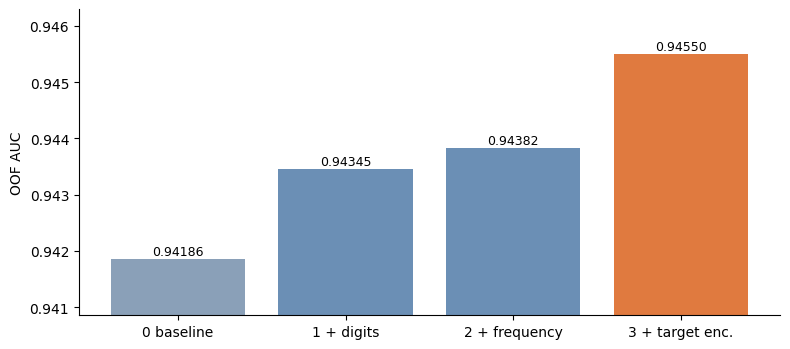

gain per rung: ['+0.00160', '+0.00037', '+0.00168'] | total: +0.00364


In [5]:
labels, vals = list(results), list(results.values())
fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(labels, vals, color=["#8aa0b8", "#6b8fb5", "#6b8fb5", "#e07a3f"])
ax.set_ylim(min(vals) - 0.001, max(vals) + 0.0008); ax.set_ylabel("OOF AUC")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.00008, f"{v:.5f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
gains = np.diff(vals)
print("gain per rung:", [f"{g:+.5f}" for g in gains], "| total:", f"{vals[-1] - vals[0]:+.5f}")

**What the ladder shows (same LightGBM, only features change):** baseline ≈ 0.9419 → digits ≈ +0.0016 → frequency ≈ +0.0004 → in-fold target encoding ≈ **+0.0017**, ending near 0.9455. The two biggest single steps are digits and target encoding; frequency encoding is small here (it was larger in the XGBoost write-up I credited, so don't assume it transfers).

**Why digits help, honestly:** a lot of the apparent digit signal is the income floor. With all rows, the buy rate by last income digit ranges from 12.2% to 19.8%; excluding the 30,000 rows it narrows to 17.3%-19.8%. So part of "digits" is a cheap way to flag round-number clipping, and part is a genuine but weaker pattern. The 0.0016 gain is what matters; the mechanism is less clean than the public write-ups suggest.

**Target encoding works because** the numeric columns have thousands of distinct values (income has ~13k); encoding each value by its smoothed buy rate gives the trees a denoised view they can't build from raw splits alone.

## 5. Submission (rung 3 model)

In [6]:
submission = pd.DataFrame({"id": test["id"], "Will_Buy_EV": test_pred})
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub) and (submission["id"].values == sample_sub["id"].values).all()
assert submission["Will_Buy_EV"].between(0, 1).all() and submission["Will_Buy_EV"].notna().all()
submission.to_csv("submission.csv", index=False)
print(submission.shape); submission.head()

(286571, 2)


,id,Will_Buy_EV
0,668665,0.033426
1,668666,0.013785
2,668667,0.003759
3,668668,0.003225
4,668669,0.026627


## 6. Takeaways
- **Public leaderboard top ≈ one prediction.** Blends correlate ≥ 0.9995; fourth-decimal gaps are not evidence of a better model.
- **Measured single-model ladder:** digits (+0.0016) and in-fold target encoding (+0.0017) are the big steps on LightGBM; frequency encoding is small (+0.0004).
- **The data has hard structure** (two floors, three cliffs). Trees find most of it on their own, so explicit flags add little.
- **Next steps:** a second model family (XGBoost or CatBoost) on the same features, then blend on OOF; more TE smoothing levels and TE on digit columns.

## ⚠️ Notes
- Metric is ROC AUC (inferred from the probability-valued sample submission); confirm on the Evaluation tab.
- Section 3 is a static table computed offline from public notebooks' outputs; it isn't reproducible inside this notebook.
- All other numbers are computed live in the cells above from the competition data. CV numbers can vary in the 5th decimal between runs (threading).
- Credit: the feature ladder idea follows the public "S6E9 single XGB CV 0.94607" notebook.